Dean Hickman

Fall 2024

CS 251: Data Analysis and Visualization

Project 3: Linear regression

Polynomial regression

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

from data import Data
import linear_regression

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.rcParams.update({'font.size': 20})

np.set_printoptions(suppress=True, precision=5)

# Automatically reload external modules
%load_ext autoreload
%autoreload 2

## Task 3: Polynomial Regression

We have been creating linear regression fits of form $y =c_0 + c_1x_1 + c_2x_2 + \ldots$, where $x_i$ are independent variables (columns of $A$) and $c_i$ are corresponding coefficients in $c$. However, this equation only allows us to fit data with a line/plane. This may not be the best choice for all datasets.

In this task, you will generalize the linear regression model form to include higher-degree (>1) polynomial terms and explore how this may improve fits to complex data. For example, assume we're doing a simple linear regression with independent variable $x_1$ and dependent variable $y$. A linear regression that fits data with a quadratic shape has the form$$y = c_0 + c_1x_1 + c_2x_1^2$$

Complete the following steps to add support for polynomial regression in your `LinearRegression` class.

### 3a. Build the polynomial matrix of the independent variable

The polynomial matrix contains the independent variable raised to a different power in each column. For example, if $A$ originally has a column vector for the independent variable $\vec{x_1}$ ($A = [\vec{x_1}]$) and we wanted to make the above quadratic model, we would append $x_1^2$ ($A = [\vec{x_1}, \vec{x_1^2}]$).

**TODO:**
Implement and test `LinearRegression::make_polynomial_matrix` (*helper method*) that takes care of raising the independent variable samples to different powers.

##### Test `make_polynomial_matrix`

In [2]:
test_A = np.r_[1:10].reshape((9, 1))
test_p = 3

# Test cubic
lin_reg = linear_regression.LinearRegression(Data())
print(f'Your polynomial matrix:\n{lin_reg.make_polynomial_matrix(test_A, 3)}')

true_mat = '''
[[  1.   1.   1.]
 [  2.   4.   8.]
 [  3.   9.  27.]
 [  4.  16.  64.]
 [  5.  25. 125.]
 [  6.  36. 216.]
 [  7.  49. 343.]
 [  8.  64. 512.]
 [  9.  81. 729.]]
'''
print('It should look like:\n', true_mat)

Your polynomial matrix:
[[  1.   1.   1.]
 [  2.   4.   8.]
 [  3.   9.  27.]
 [  4.  16.  64.]
 [  5.  25. 125.]
 [  6.  36. 216.]
 [  7.  49. 343.]
 [  8.  64. 512.]
 [  9.  81. 729.]]
It should look like:
 
[[  1.   1.   1.]
 [  2.   4.   8.]
 [  3.   9.  27.]
 [  4.  16.  64.]
 [  5.  25. 125.]
 [  6.  36. 216.]
 [  7.  49. 343.]
 [  8.  64. 512.]
 [  9.  81. 729.]]



### 3b. Add support for polynomial regression

This can be performed in 3 steps:


1. Implement the `LinearRegression::polynomial_regression` method to perform the polynomial regression (*alternate option: you may instead update your `linear_regression` method. If you decide to go this route, add a keyword argument for the polynomial degree with a default value of 1 to preserve compatability with regular linear regression.*).
2. Update `LinearRegression::predict`: Run `make_polynomial_matrix` on the "A" matrix that enters into the computation $y = Ac$ if `self.p > 1`.
3. Add support for plotting polynomials in `LinearRegression::scatter` by generalizing the plotted regression line to a regression polynomial if `self.p > 1`:
    - Getting your polynomial "x" values: Run `make_polynomial_matrix` on your evenly-spaced line sample points. To get the shapes to work out, you may need to add a trailing singleton dimension to your "x" sample points. For example, if you have 1000 "x" sample points, make the shape `(1000, 1)` rather than `(1000,)`.
    - Getting your polynomial "y" values: Use matrix multiplication with your polynomial regression model slopes and/or intercepts.

*There is no explicit test code here — visualizing the fit in the next subtask will help you debug!*

### 3c. Run a polynomial regression

In this subtask, you will debug your polynomial regression implementation and experiment fitting some data with it.

#### Test: Polynomial regression with linear model ($p = 1$)

- In the cell below, fit the `poly_data.csv` dataset using polynomial regression where the polynomial degree $p = 1$.
- Use `scatter` to plot the results.
- Print out the mean squared error.

The plot created by running the below cell should "look right" to you.

Mean Squared Error: 71.81095284569933


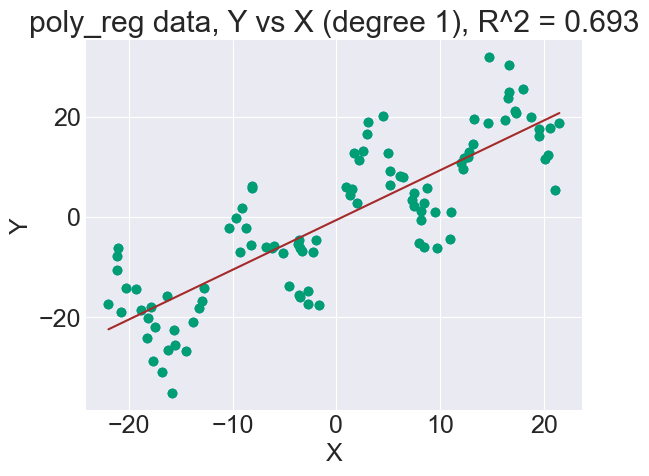

In [3]:
poly_data= Data('data/poly_data.csv')
poly_reg= linear_regression.LinearRegression(poly_data)

poly_reg.poly_regression('X', 'Y', 1)
poly_reg.scatter('X', 'Y', 'poly_reg data, Y vs X (degree 1)')
mse= poly_reg.compute_mse()
print(f'Mean Squared Error: {mse}')


#### Test: polynomial regression with high degree polynomials

Repeat the steps from the $p = 1$ test above in the cell below, but this time try $p = 7$. 

*Your regression fit should not be a line!*

Mean Squared Error: 55.030880732781014


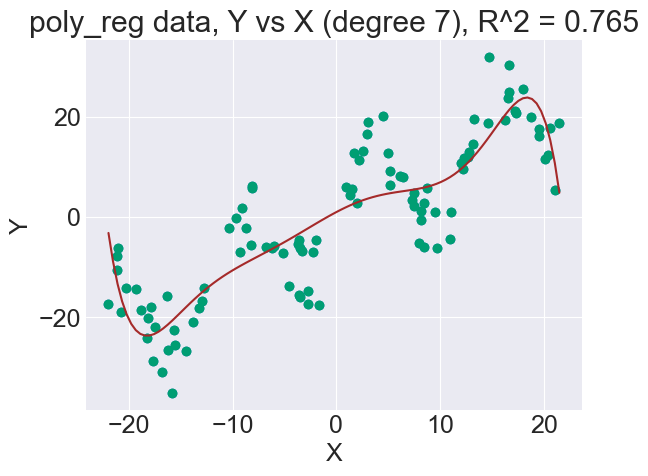

In [4]:
poly_reg.poly_regression('X', 'Y', 7)
poly_reg.scatter('X', 'Y', 'poly_reg data, Y vs X (degree 7)')
mse= poly_reg.compute_mse()
print(f'Mean Squared Error: {mse}')

### 3d. Questions

**Question 5:** Describe the `p=7` fit compared to `p=1` — is it better or worse? Why?

**Question 6:** Describe what happens visually to the shape of the regression curve and in relation to the data as you experiment with the polynomial degree between 1 and 7. 

**Question 7:** Create and interpret a plot showing the MSE values as the polynomial degree goes from 1 to 7.

**Answer 5:** The p=7 plot is better than the p=1 because it has a lower mse. This means that the model's prediction of the data values is closer to the actual data values. By inspection this makes sense, p=7 is a polynomial of degree 7 which better fits the non-linearity of the data that is plotted. p=1 is a polynomial of degree 1 which is just a line, if the data is non-linear how good would a line model it?

**Answer 6:** As we increase p the regression curve starts to actually curve and weave its way through the data. This makes it appear that the regression curve is following the general shape of the data. Every time we change p it looks like the curve is picking out more points to follow. 

**Answer 7:** 


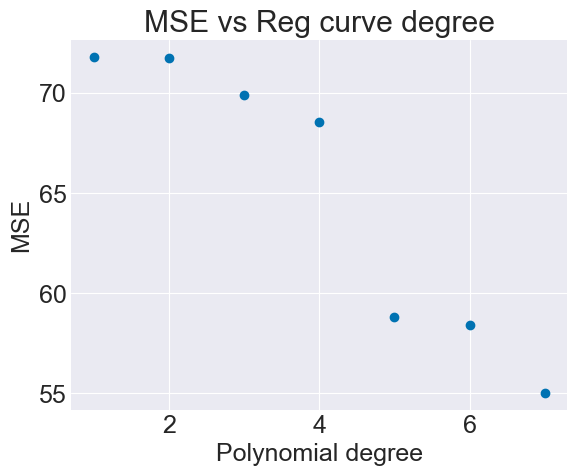

In [5]:
mse = []
deg = []
i= 1
while i <= 7:
    poly_reg.poly_regression('X', 'Y', i)
    mse.append(poly_reg.compute_mse())
    deg.append(i)
    i+=1
    
plt.scatter(deg, mse)
plt.title('MSE vs Reg curve degree')
plt.ylabel('MSE')
plt.xlabel('Polynomial degree')
plt.show()

## Task 4: Overfitting

In this subtask, you will experiment with how polynomial regression generalize to data not used to fit the regression model.

### 4a. Create fit and validation sets

The `poly_data.csv` dataset has 100 samples ($N=100$). In the cell below, split these samples into two separate "datasets" and create 2 `Data` objects representing:
- The first 50% of samples will be used to fit the regression model (i.e. run linear regression on these samples). We will call this the **fit set** (data used to fit the regression).
- The second 50% of samples will be set aside and only used to check how well the fitted regression generalizes to new data. We will call this the **validation set**.

The data samples are already shuffled.

*Hint: There is a helpful `Data` method for paring down a dataset into a certain range of samples.*

In [6]:
fit_data= Data('data/poly_data.csv')
fit_data.limit_samples(0, 50)
val_data= Data('data/poly_data.csv')
val_data.limit_samples(50, 100)
print(f'{fit_data}, \n{val_data}')


X,Y
2.147,11.382
9.465,1.034
4.52,20.251
1.974,2.89
-3.358,-6.809, 
X,Y
-3.65,-4.658
9.69,-6.107
-21.986,-17.271
-8.694,-2.22
-15.536,-25.608


Printing the `Data` object storing the fit set should yield:

    -------------------------------
    data/polydata.csv (50x2)
    Headers:
    X	Y
    Types:
    numeric	numeric
    -------------------------------
    Showing first 5/50 rows.
    2.147	11.382
    9.465	1.034
    4.52	20.251
    1.974	2.89
    -3.358	-6.809

    -------------------------------

Printing the `Data` object storing the validation set should yield:

    -------------------------------
    data/polydata.csv (50x2)
    Headers:
    X	Y
    Types:
    numeric	numeric
    -------------------------------
    Showing first 5/50 rows.
    -3.65	-4.658
    9.69	-6.107
    -21.986	-17.271
    -8.694	-2.22
    -15.536	-25.608

    -------------------------------

### 4b. Check fit generalization on validation set

Here is the process for checking how well your fitted linear regression model generalizes to the validation data:
1. Create `Data` objects for both the fit and validation data sets (*as you have already done*).
2. Run linear regression on the fit set.
3. Create a new `LinearRegression` object associated with the validation data.
4. Copy over the fitted slope and intercept coefficients associated with the fit set to the validation set `LinearRegression` object.
5. Create a scatterplot by calling `scatter` to show the validation data and the regression curve that uses the coefficients fitted on the fit dataset (copied over in Step 4).
6. Calculate and report fit statistics (e.g. MSE, $R^2$).

Before doing this, implement the following methods to help you copy over the fitted slope, intercept and other data from your fit set `LinearRegression` object:

- `get_fitted_slope`: return the fitted regression slopes.
- `get_fitted_intercept`: return the fitted regression intercept.
- `initialize(ind_vars, dep_var, slope, intercept, p)`: set fields based on passed in parameter values.

#### Check overfitting with $p = 7$ polynomial regression model

In the cell below:

1. Fit a polynomial regression model with $p = 7$ on the fit set.
2. Create 2 scatter plots:
    - Showing the fit set and regression curve fitted to it.
    - Showing the validation set and regression curve that uses the fitted coefficients to the **fit set**.
3. Compute and print the MSE for both the fit and validation sets.

Use the 6 step process above to guide you through the setup.

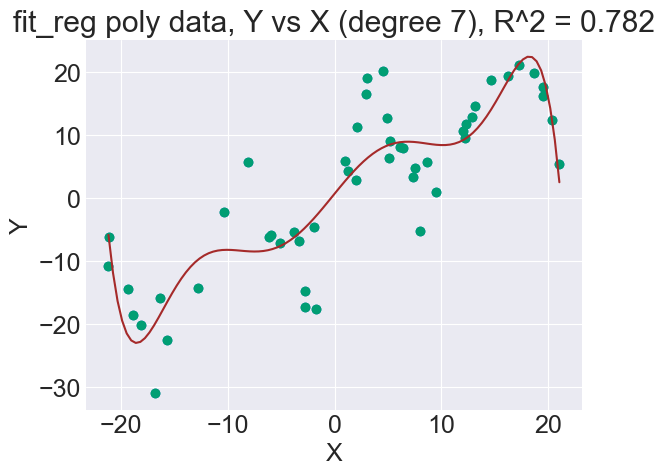

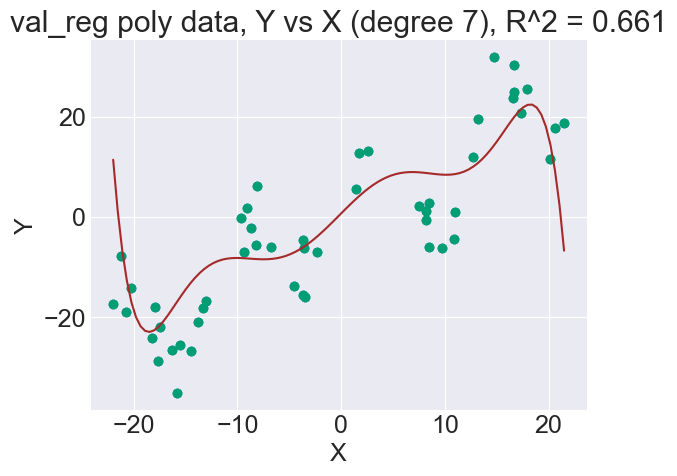

fit_data mse: 38.30258184051851
val_data mse: 96.45877456854069


In [7]:
fit_reg = linear_regression.LinearRegression(fit_data)
val_reg = linear_regression.LinearRegression(val_data)


fit_reg.poly_regression('X', 'Y', 7)
fit_m = fit_reg.get_fitted_slope()
fit_b = fit_reg.get_fitted_intercept()
fit_mse = fit_reg.compute_mse()
fit_reg.scatter('X', 'Y', 'fit_reg poly data, Y vs X (degree 7)')
plt.show()

val_reg.poly_regression('X', 'Y', 7)
val_reg.initialize('X', 'Y', fit_m, fit_b, 7)
val_reg.r_squared(val_reg.predict())
val_mse = val_reg.compute_mse()
val_reg.scatter('X', 'Y', 'val_reg poly data, Y vs X (degree 7)')
plt.show()

print(f'fit_data mse: {fit_mse}')
print(f'val_data mse: {val_mse}')

### 4c. Questions

**Question 8:** Describe how the fitted coefficients obtained for the fit set generalize to the validation set. Do they do a good or bad job? Why?

**Question 9:** Does the generalization improve or worsen for polynomial degrees < 7? Are Back up your observations with numbers (e.g. MSE, $R^2$).

**Question 10:** Are there any values/ranges of polynomial degrees that generalize acceptably to the validation set? Why do you think so?

**Question 11:** What happens when you increase the polynomial degree above 7, in the range $7-13$? Why do you think this happens? Back up your observations with numbers (e.g. MSE, $R^2$).

**Answer 8:** The fitted coefficients for the fit set do not generalize that well to the validation set. If you look at the difference in MSE and R^2 values you will observe that the validation set has a higher MSE and a lower R^2 value than the fit set. If they generalized well then we would expect that the validation set had a lower MSE and R^2 value than the fit set. This actually helps us to make claims about how the first 50 samples differ from the second 50 samples.

**Answer 9:** For polynomial degree less than 7 the generalizations tend to improve. This can be seen in a lower MSE value and a higher R^2 value. If we look just at degree 6 we can observe a MSE of about 79.18 and an R^2 of about 0.72, which is an improvement from the MSE of 96.45 and R^2 of 0.661 that we saw for the same data at a degree of 7. This may happen becuase the validation set is a different section of the dataset and may not need to have such a high degree to capture its trends. So the way that we split the data, an arbitrary choice, is a telling one in terms of the dataset at large. Please observe the empirical data below for more information.


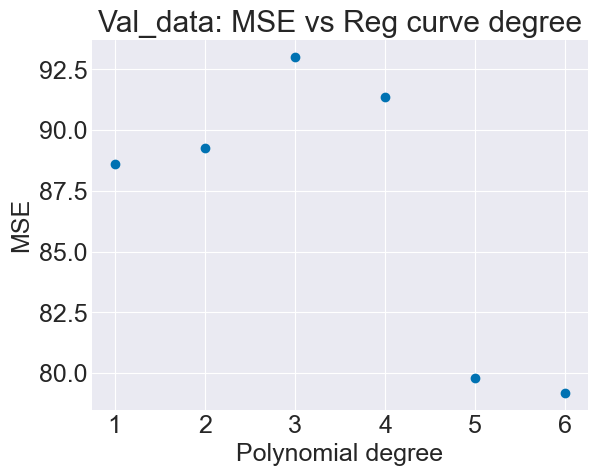

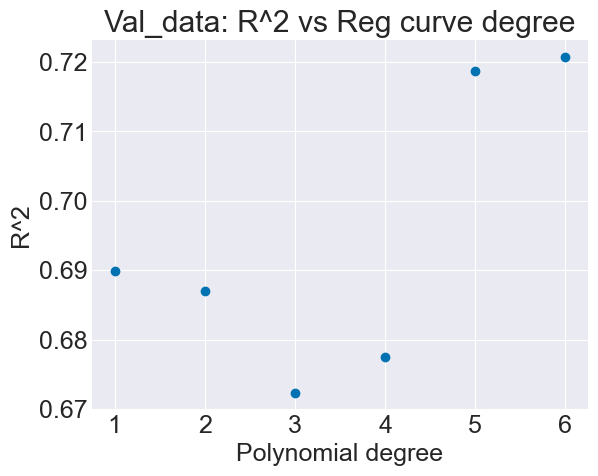

MSE: [88.58467771864787, 89.27378847228445, 93.01736764114841, 91.37791686898116, 79.8181777017864, 79.18969400684779]
R^2: [0.6898059661789065, 0.6870068034262018, 0.6723280668927643, 0.6774525411575494, 0.7187371975934207, 0.7207127353262475]


In [8]:
fit_reg = linear_regression.LinearRegression(fit_data)
val_reg = linear_regression.LinearRegression(val_data)

v_mse = []
v_R2 = []
deg = []
i= 1
while i <7:
    fit_reg.poly_regression('X', 'Y', i)
    fit_m = fit_reg.get_fitted_slope()
    fit_b = fit_reg.get_fitted_intercept()

    val_reg.poly_regression('X', 'Y', i)
    val_reg.initialize('X', 'Y', fit_m, fit_b, i)
    v_mse.append(val_reg.compute_mse())
    v_R2.append(val_reg.r_squared(val_reg.predict()))
    
    deg.append(i)
    i+=1

plt.scatter(deg, v_mse)
plt.title('Val_data: MSE vs Reg curve degree')
plt.ylabel('MSE')
plt.xlabel('Polynomial degree')
plt.show()
plt.scatter(deg, v_R2)
plt.title('Val_data: R^2 vs Reg curve degree')
plt.ylabel('R^2')
plt.xlabel('Polynomial degree')
plt.show()
print(f'MSE: {v_mse}')
print(f'R^2: {v_R2}')

**Answer 10:** Yes, the degree 5 and 6 are acceptable generalizations to the valid set because they have the highest R^2 values and the lowest MSE values. This means that their predictions of the data values are closer to the actual values of the data and they explain a larger proportion of the variance in the dep_var than compared to other models of a lower or higher degree. This is a sweet spot if you will, where we don't overfit or underfit. 

**Answer 11:** We are going to see a lot of overfitting with degrees this high, because the data is just not that complex. There is probably a range that makes sense for this data say from 5 - 10, but anything over that will be too complex and capture patterns in the data that can't be generalized well hence the overfitting. Take for instance the polynomial at degree 13, it has an MSE of 218.28 and a R^2 of 0.24 this is a bad combination. The best numbers we have seen in the range of degrees from 1 to 14 is degree 9 because it has the lowest MSE (37.87) and the highest R^2 (0.86) which is completely different than what we see when the model is performing its worst.

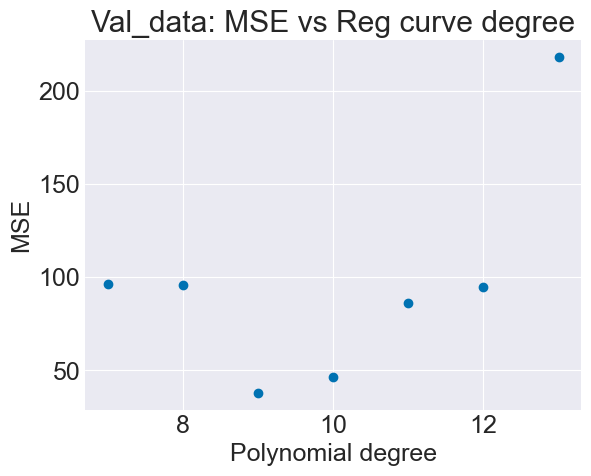

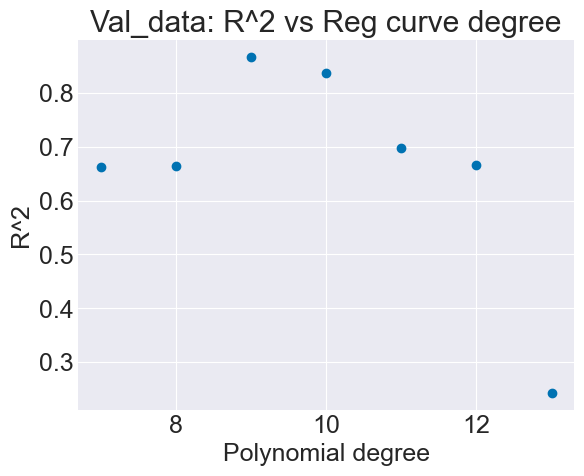

MSE: [96.45877456854069, 95.50846396440704, 37.8778805799413, 46.24646736737612, 86.2342499846291, 94.93929980528331, 218.28792472459958]
R^2: [0.6613794748072235, 0.6645453423970975, 0.8668671311164321, 0.8370338675054134, 0.6966315779349761, 0.6668369689474836, 0.24297402552913683]


In [10]:
fit_reg = linear_regression.LinearRegression(fit_data)
val_reg = linear_regression.LinearRegression(val_data)

v_mse = []
v_R2 = []
deg = []
i= 7
while i <= 13 :
    fit_reg.poly_regression('X', 'Y', i)
    fit_m = fit_reg.get_fitted_slope()
    fit_b = fit_reg.get_fitted_intercept()

    val_reg.poly_regression('X', 'Y', i)
    val_reg.initialize('X', 'Y', fit_m, fit_b, i)
    v_mse.append(val_reg.compute_mse())
    v_R2.append(val_reg.r_squared(val_reg.predict()))
    
    deg.append(i)
    i+=1

plt.scatter(deg, v_mse)
plt.title('Val_data: MSE vs Reg curve degree')
plt.ylabel('MSE')
plt.xlabel('Polynomial degree')
plt.show()
plt.scatter(deg, v_R2)
plt.title('Val_data: R^2 vs Reg curve degree')
plt.ylabel('R^2')
plt.xlabel('Polynomial degree')
plt.show()
print(f'MSE: {v_mse}')
print(f'R^2: {v_R2}')